Importing Necessary Libraries

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from matplotlib.pyplot import subplots
import sklearn.model_selection as skm
from sklearn.tree import (DecisionTreeClassifier as DTC, DecisionTreeRegressor as DTR, plot_tree, export_text)
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, log_loss)
from ISLP import confusion_table
from sklearn.ensemble import (RandomForestClassifier as RF, GradientBoostingClassifier as GBC)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay

In [58]:
cmc = pd.read_csv('/home/dsamuelchin/Documents/Data 645/Unit 6/cmc.csv')

Basic Information

In [59]:
cmc.shape

(1473, 10)

In [60]:
cmc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   WifeAge              1473 non-null   int64
 1   WifeEducation        1473 non-null   int64
 2   HusbandEducation     1473 non-null   int64
 3   NumChildren          1473 non-null   int64
 4   WifeReligion         1473 non-null   int64
 5   WifeWorking          1473 non-null   int64
 6   HusbandOccupation    1473 non-null   int64
 7   LivingStandardIndex  1473 non-null   int64
 8   MediaExposure        1473 non-null   int64
 9   ContraceptiveMethod  1473 non-null   int64
dtypes: int64(10)
memory usage: 115.2 KB


In [61]:
cmc.head()

,WifeAge,WifeEducation,HusbandEducation,NumChildren,WifeReligion,WifeWorking,HusbandOccupation,LivingStandardIndex,MediaExposure,ContraceptiveMethod
0,24,2,3,3,1,1,2,3,0,1
1,45,1,3,10,1,1,3,4,0,1
2,43,2,3,7,1,1,3,4,0,1
3,42,3,2,9,1,1,3,3,0,1
4,36,3,3,8,1,1,3,2,0,1


In [62]:
cmc.columns

Index(['WifeAge', 'WifeEducation', 'HusbandEducation', 'NumChildren',
       'WifeReligion', 'WifeWorking', 'HusbandOccupation',
       'LivingStandardIndex', 'MediaExposure', 'ContraceptiveMethod'],
      dtype='object')

In [63]:
cmc.dtypes

WifeAge                int64
WifeEducation          int64
HusbandEducation       int64
NumChildren            int64
WifeReligion           int64
WifeWorking            int64
HusbandOccupation      int64
LivingStandardIndex    int64
MediaExposure          int64
ContraceptiveMethod    int64
dtype: object

In [64]:
cmc.describe()

,WifeAge,WifeEducation,HusbandEducation,NumChildren,WifeReligion,WifeWorking,HusbandOccupation,LivingStandardIndex,MediaExposure,ContraceptiveMethod
count,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000
mean,32.538357,2.958588,3.429735,3.261371,0.850645,0.749491,2.137814,3.133741,0.073999,1.919891
std,8.227245,1.014994,0.816349,2.358549,0.356559,0.433453,0.864857,0.976161,0.261858,0.876376
min,16.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,26.000000,2.000000,3.000000,1.000000,1.000000,0.000000,1.000000,3.000000,0.000000,1.000000
50%,32.000000,3.000000,4.000000,3.000000,1.000000,1.000000,2.000000,3.000000,0.000000,2.000000
75%,39.000000,4.000000,4.000000,4.000000,1.000000,1.000000,3.000000,4.000000,0.000000,3.000000
max,49.000000,4.000000,4.000000,16.000000,1.000000,1.000000,4.000000,4.000000,1.000000,3.000000


In [65]:
cmc.isna().sum()

WifeAge                0
WifeEducation          0
HusbandEducation       0
NumChildren            0
WifeReligion           0
WifeWorking            0
HusbandOccupation      0
LivingStandardIndex    0
MediaExposure          0
ContraceptiveMethod    0
dtype: int64

Label Modifications

In [66]:
qual_cols = ['WifeEducation', 'HusbandEducation', 'WifeReligion', 
             'WifeWorking', 'HusbandOccupation', 'LivingStandardIndex', 'MediaExposure',
             'ContraceptiveMethod']

for col in qual_cols:
    cmc[col] = cmc[col].astype('category')

In [67]:
mappings = {
    'WifeEducation':{1:'low', 2:'medium low', 3:'medium high', 4:'high'},
    'HusbandEducation':{1:'low', 2:'medium low', 3:'medium high', 4:'high'},
    'WifeReligion':{0:'Non-Islam', 1:'Islam'},
    'WifeWorking':{0:'Yes', 1:'No'},
    'HusbandOccupation':{1:'low', 2:'medium low', 3:'medium high', 4:'high'},
    'LivingStandardIndex':{1:'low', 2:'medium low', 3:'medium high', 4:'high'},
    'MediaExposure':{0:'good', 1:'not good'},
    }
target_mapping = {1:'no use', 2:'long term', 3:'short term'}
plot_df = cmc.copy()

for col, mapping in mappings.items():
    plot_df[f'{col}_label'] = plot_df[col].map(mapping)

plot_df['ContraceptiveMethod_label'] = plot_df['ContraceptiveMethod'].map(target_mapping)

Creating Visuals for EDA

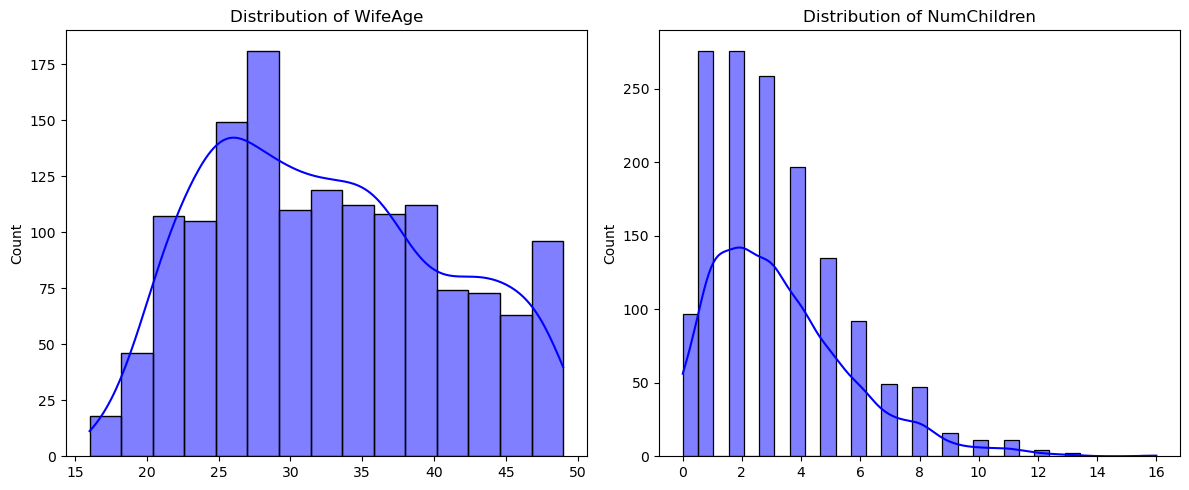

In [68]:
numeric_cols = ['WifeAge','NumChildren']

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(cmc[col], kde=True, ax=axes[i], color='blue', shrink=1)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

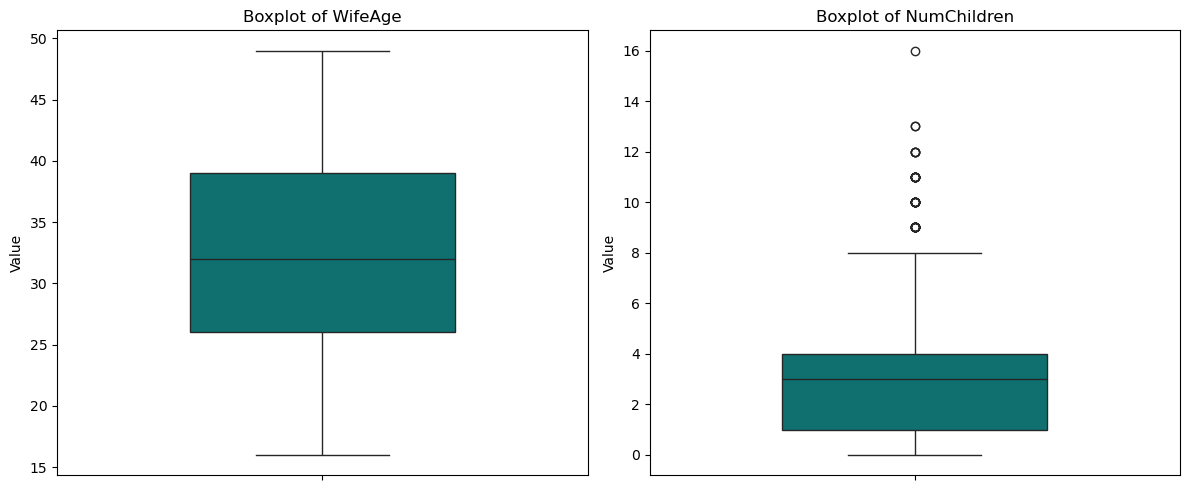

In [69]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=cmc[col], ax=axes[i], color='teal', width=0.5)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.savefig('boxplots.png', dpi=300)
plt.show()

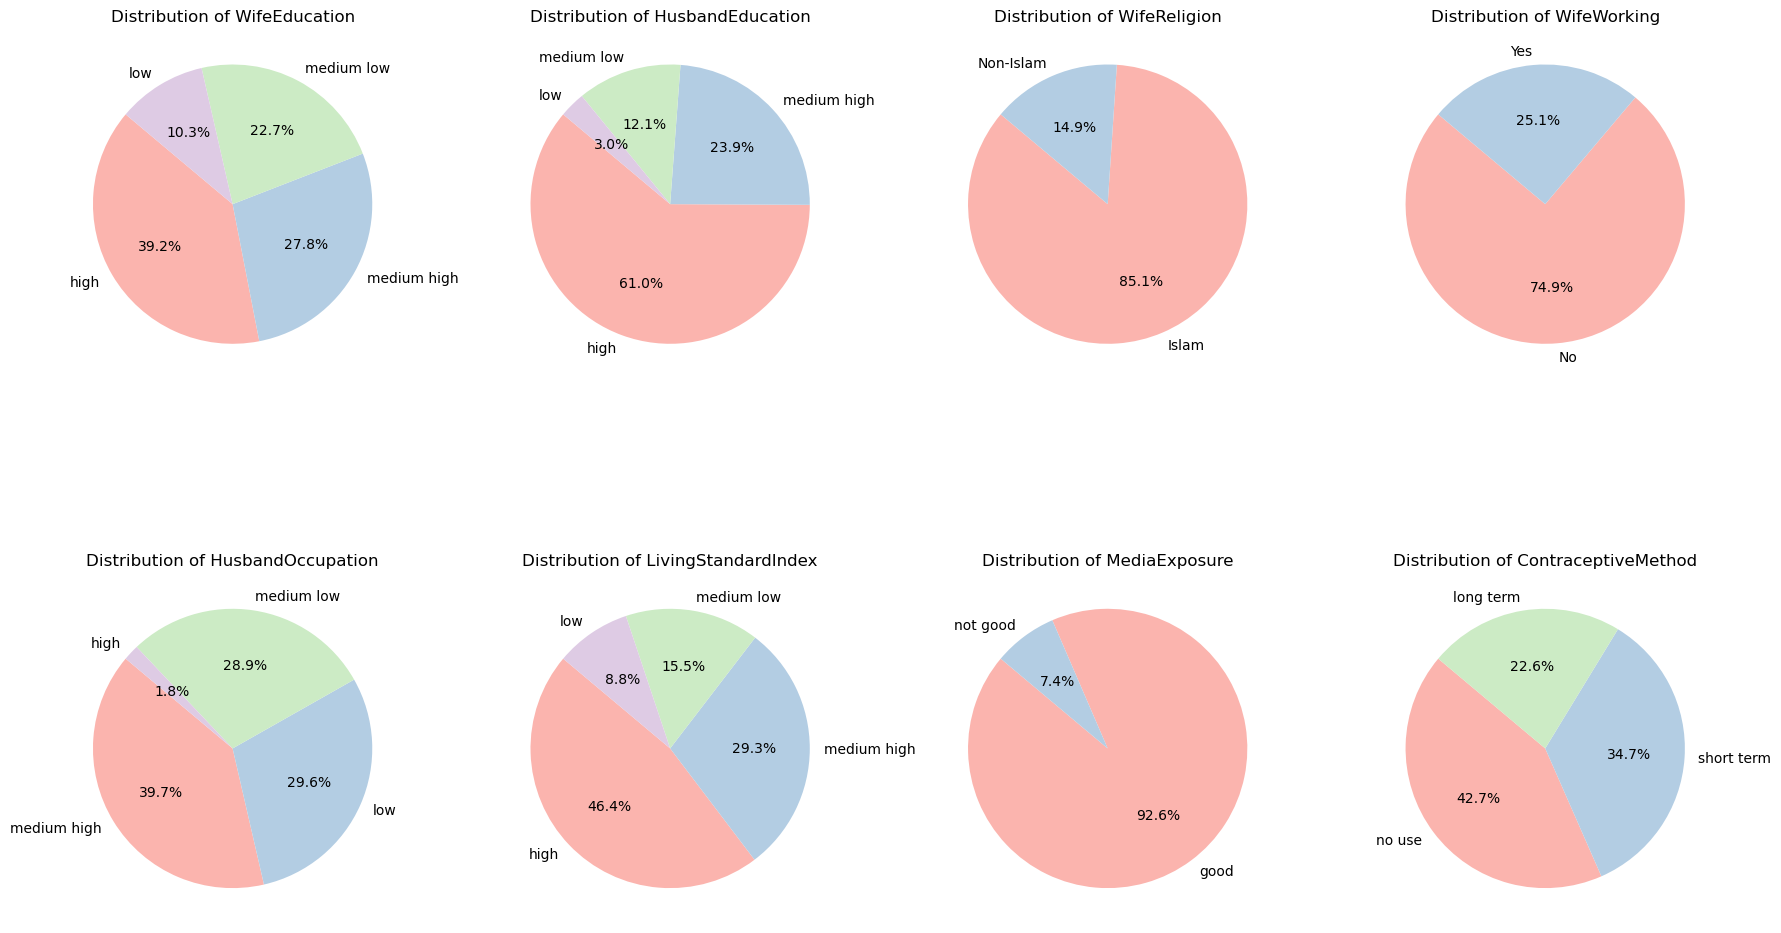

In [70]:
category_cols = ['WifeEducation','HusbandEducation','WifeReligion','WifeWorking','HusbandOccupation','LivingStandardIndex','MediaExposure','ContraceptiveMethod']

fig, axes = plt.subplots(2,4, figsize=(18,12))
axes = axes.flatten()

for i, col in enumerate(category_cols):
    label_col = f'{col}_label'
    counts = plot_df[label_col].value_counts()

    axes[i].pie(counts,labels=counts.index, autopct='%1.1f%%',startangle=140, colors=plt.cm.Pastel1.colors, textprops={'fontsize':10})
    axes[i].set_title(f'Distribution of {col}', fontsize=12)

plt.tight_layout()
plt.savefig('category_piechart.png', dpi=300, bbox_inches='tight')
plt.show()
        

INITIAL MODELING (Decision Tree with Max Depth)

In [83]:
to_drop = ['ContraceptiveMethod', 'ContraceptiveMethod_label']
X_raw = cmc.drop(columns=to_drop, errors='ignore')

model = MS(X_raw.columns, intercept=False)
D = model.fit_transform(X_raw)

feature_names = list(D.columns)
X = D.values 
y = cmc['ContraceptiveMethod']

clf = DTC(criterion='entropy', max_depth=3, random_state=0)
clf.fit(X, y)

print(f"Initial Accuracy: {accuracy_score(y, clf.predict(X))}")
resid_dev = np.sum(log_loss(y, clf.predict_proba(X)))
print(f"Initial Residual Deviance: {resid_dev}")

Initial Accuracy: 0.539714867617108
Initial Residual Deviance: 0.9236370075998386


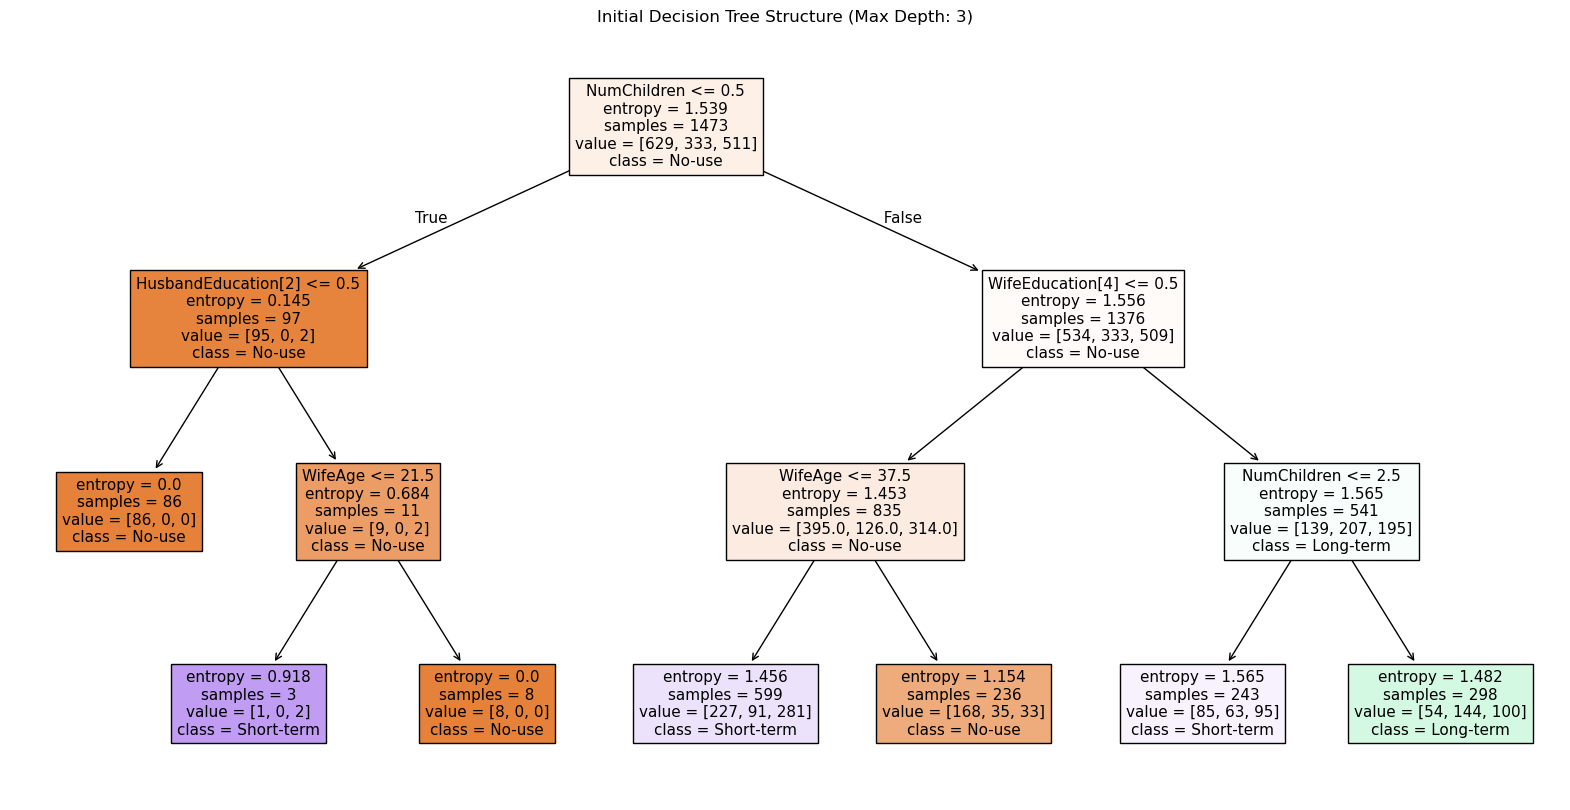


--- Text Representation of the Initial Tree ---
|--- NumChildren <= 0.50
|   |--- HusbandEducation[2] <= 0.50
|   |   |--- weights: [86.00, 0.00, 0.00] class: 1
|   |--- HusbandEducation[2] >  0.50
|   |   |--- WifeAge <= 21.50
|   |   |   |--- weights: [1.00, 0.00, 2.00] class: 3
|   |   |--- WifeAge >  21.50
|   |   |   |--- weights: [8.00, 0.00, 0.00] class: 1
|--- NumChildren >  0.50
|   |--- WifeEducation[4] <= 0.50
|   |   |--- WifeAge <= 37.50
|   |   |   |--- weights: [227.00, 91.00, 281.00] class: 3
|   |   |--- WifeAge >  37.50
|   |   |   |--- weights: [168.00, 35.00, 33.00] class: 1
|   |--- WifeEducation[4] >  0.50
|   |   |--- NumChildren <= 2.50
|   |   |   |--- weights: [85.00, 63.00, 95.00] class: 3
|   |   |--- NumChildren >  2.50
|   |   |   |--- weights: [54.00, 144.00, 100.00] class: 2



In [72]:
fig, ax = subplots(figsize=(20, 10))
plot_tree(clf, 
          feature_names=feature_names, 
          class_names=['No-use', 'Long-term', 'Short-term'], 
          filled=True, 
          ax=ax)
ax.set_title("Initial Decision Tree Structure (Max Depth: 3)")
plt.show()

print("\n--- Text Representation of the Initial Tree ---")
print(export_text(clf, feature_names=feature_names, show_weights=True))

MODIFIED MODELING (Pruned Decision Tree)

In [73]:
(X_train, X_test, y_train, y_test) = skm.train_test_split(X, y, test_size=0.5, random_state=0)

clf_full = DTC(criterion='entropy', random_state=0)
clf_full.fit(X_train, y_train)

ccp_path = clf_full.cost_complexity_pruning_path(X_train, y_train)
kfold = skm.KFold(10, random_state=1, shuffle=True)

grid = skm.GridSearchCV(clf_full, {'ccp_alpha': ccp_path.ccp_alphas}, refit=True, cv=kfold, scoring='accuracy')
grid.fit(X_train, y_train)

best_tree = grid.best_estimator_

tree_probs = best_tree.predict_proba(X_test)
tree_deviance = log_loss(y_test, tree_probs)

print(f"Pruned Tree Test Accuracy: {accuracy_score(y_test, best_tree.predict(X_test))}")
print(f"Pruned Tree Deviance (Log Loss): {tree_deviance}")

Pruned Tree Test Accuracy: 0.5318860244233379
Pruned Tree Deviance (Log Loss): 1.138076315443879


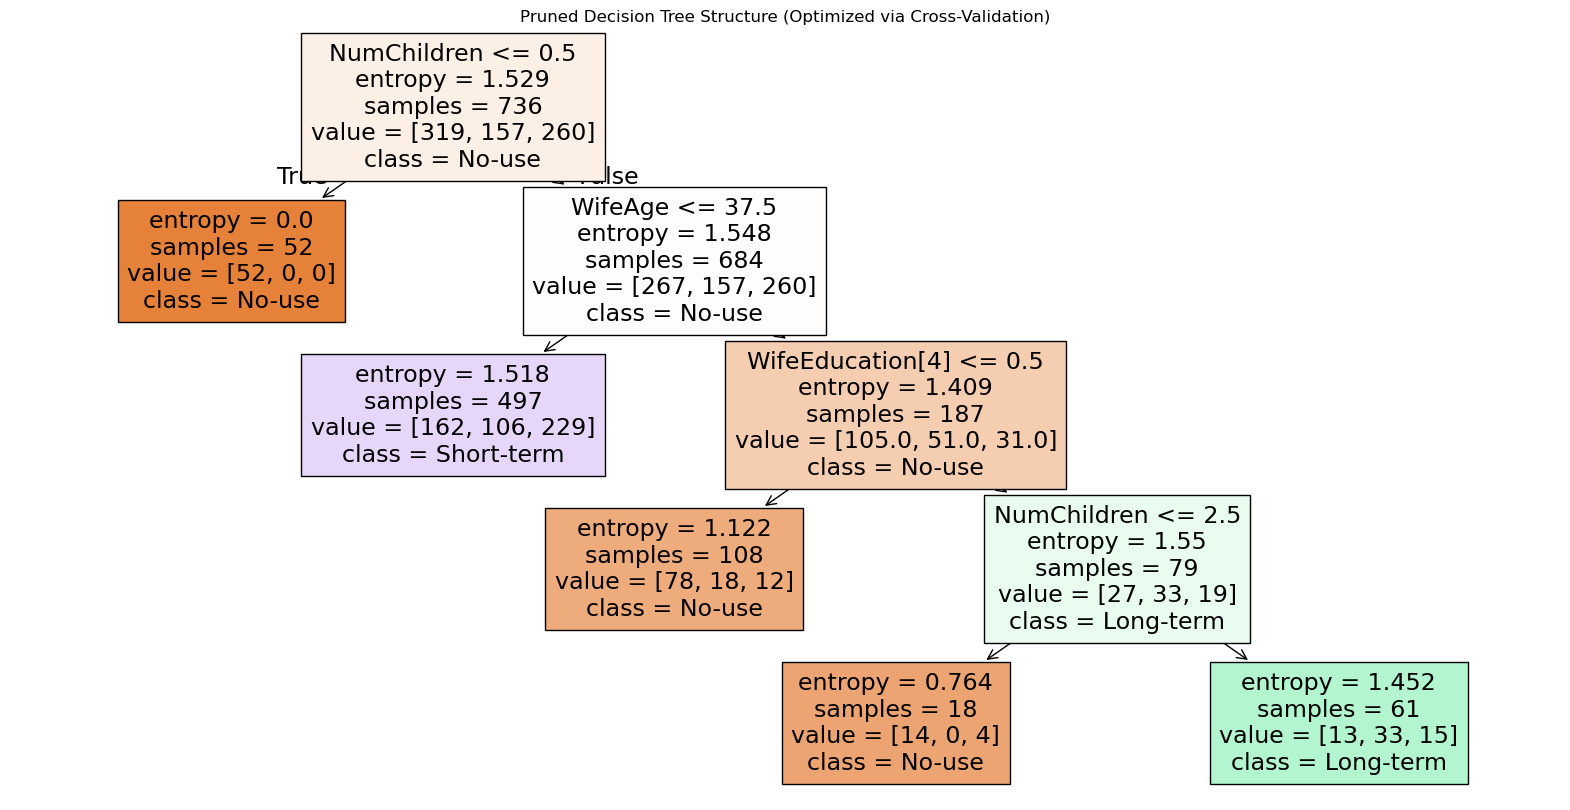


--- Text Representation of the Pruned Tree ---
|--- NumChildren <= 0.50
|   |--- weights: [52.00, 0.00, 0.00] class: 1
|--- NumChildren >  0.50
|   |--- WifeAge <= 37.50
|   |   |--- weights: [162.00, 106.00, 229.00] class: 3
|   |--- WifeAge >  37.50
|   |   |--- WifeEducation[4] <= 0.50
|   |   |   |--- weights: [78.00, 18.00, 12.00] class: 1
|   |   |--- WifeEducation[4] >  0.50
|   |   |   |--- NumChildren <= 2.50
|   |   |   |   |--- weights: [14.00, 0.00, 4.00] class: 1
|   |   |   |--- NumChildren >  2.50
|   |   |   |   |--- weights: [13.00, 33.00, 15.00] class: 2



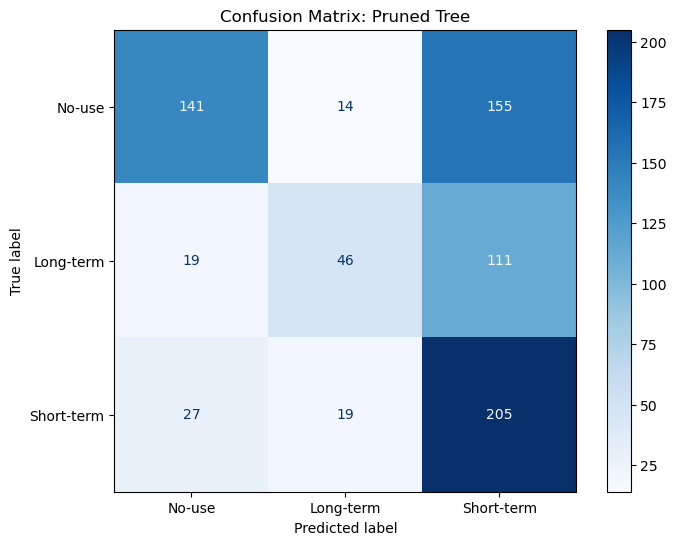

In [74]:
fig, ax = subplots(figsize=(20, 10))
plot_tree(best_tree, 
          feature_names=feature_names, 
          class_names=['No-use', 'Long-term', 'Short-term'], 
          filled=True, 
          ax=ax)
ax.set_title("Pruned Decision Tree Structure (Optimized via Cross-Validation)")
plt.show()

print("\n--- Text Representation of the Pruned Tree ---")
print(export_text(best_tree, feature_names=feature_names, show_weights=True))

fig, ax = subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_tree, 
                                      X_test, 
                                      y_test, 
                                      display_labels=['No-use', 'Long-term', 'Short-term'],
                                      cmap=plt.cm.Blues, 
                                      ax=ax)
ax.set_title("Confusion Matrix: Pruned Tree")
plt.show()

RANDOM FOREST (Tuned)

In [75]:
cmc['Age_Children_Interaction'] = cmc['WifeAge'] * cmc['NumChildren']
X_raw_rf = cmc.drop(columns=to_drop + [col for col in cmc.columns if col.endswith('_label')], errors='ignore')
D_rf = MS(X_raw_rf.columns, intercept=False).fit_transform(X_raw_rf)

X_rf = D_rf.values
X_train_rf, X_test_rf, y_train_rf, y_test_rf = skm.train_test_split(X_rf, y, test_size=0.5, random_state=0)

param_grid_rf = {
    'max_depth': [3, 5, 8, 10],
    'min_samples_leaf': [5, 10, 20],
    'n_estimators': [100, 200]
}

grid_rf = GridSearchCV(RF(random_state=0, class_weight='balanced'), param_grid_rf, cv=kfold, scoring='accuracy')
grid_rf.fit(X_train_rf, y_train_rf)

best_rf = grid_rf.best_estimator_
rf_preds = best_rf.predict(X_test_rf)

rf_probs = best_rf.predict_proba(X_test_rf)
rf_deviance = log_loss(y_test_rf, rf_probs)

print(f"Random Forest Test Accuracy: {accuracy_score(y_test_rf, rf_preds)}")
print(f"Random Forest Deviance (Log Loss): {rf_deviance}")

rf_importances = pd.DataFrame({'Feature': list(D_rf.columns), 'Importance': best_rf.feature_importances_})
print("\nTop 10 RF Features:")
print(rf_importances.sort_values(by='Importance', ascending=False).head(10))

Random Forest Test Accuracy: 0.5345997286295794
Random Forest Deviance (Log Loss): 0.9296985556896757

Top 10 RF Features:
                     Feature  Importance
17  Age_Children_Interaction    0.263858
0                    WifeAge    0.212939
7                NumChildren    0.159815
3           WifeEducation[4]    0.061957
15    LivingStandardIndex[4]    0.035178
11      HusbandOccupation[3]    0.032415
6        HusbandEducation[4]    0.029765
10      HusbandOccupation[2]    0.026313
8            WifeReligion[1]    0.025760
9             WifeWorking[1]    0.024312


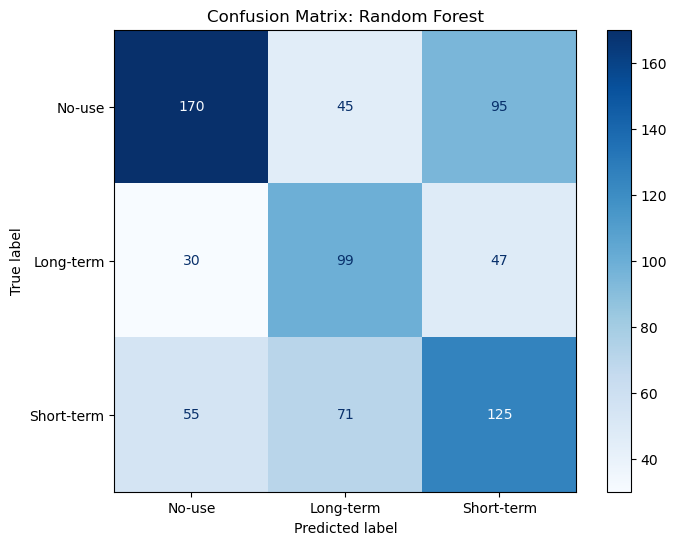

In [76]:

fig, ax = subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_rf, 
                                      X_test_rf, 
                                      y_test_rf, 
                                      display_labels=['No-use', 'Long-term', 'Short-term'],
                                      cmap=plt.cm.Blues,
                                      ax=ax)
ax.set_title("Confusion Matrix: Random Forest")
plt.show()

BOOSTING (Gradient Boosting Tuned)

In [77]:
param_grid_boost = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8, 1.0] 
}

grid_boost = GridSearchCV(GBC(random_state=0), param_grid_boost, cv=5, scoring='accuracy', n_jobs=-1)
grid_boost.fit(X_train_rf, y_train_rf)

best_boost = grid_boost.best_estimator_
boost_preds = best_boost.predict(X_test_rf)

boost_probs = best_boost.predict_proba(X_test_rf)
boost_deviance = log_loss(y_test_rf, boost_probs)

print(f"Boosting Test Accuracy: {accuracy_score(y_test_rf, boost_preds)}")
print(f"Boosting Deviance (Log Loss): {boost_deviance}")

boost_importances = pd.DataFrame({'Feature': list(D_rf.columns), 'Importance': best_boost.feature_importances_})
print("\nTop 10 Boosting Features:")
print(boost_importances.sort_values(by='Importance', ascending=False).head(10))

Boosting Test Accuracy: 0.5223880597014925
Boosting Deviance (Log Loss): 0.9566799104024039

Top 10 Boosting Features:
                     Feature  Importance
17  Age_Children_Interaction    0.391448
0                    WifeAge    0.229959
7                NumChildren    0.047190
3           WifeEducation[4]    0.046771
9             WifeWorking[1]    0.035208
2           WifeEducation[3]    0.028173
15    LivingStandardIndex[4]    0.026083
8            WifeReligion[1]    0.025561
10      HusbandOccupation[2]    0.024407
6        HusbandEducation[4]    0.023380


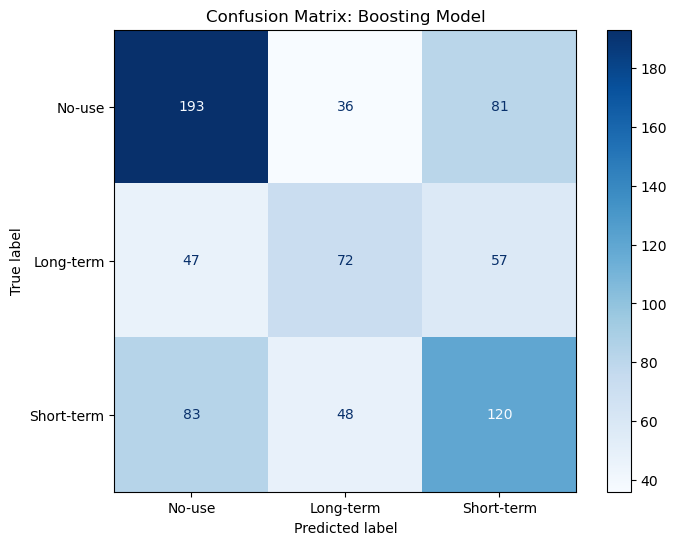

In [78]:
fig, ax = subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_boost, 
                                      X_test_rf, 
                                      y_test_rf, 
                                      display_labels=['No-use', 'Long-term', 'Short-term'],
                                      cmap=plt.cm.Blues,
                                      ax=ax)

ax.set_title("Confusion Matrix: Boosting Model")
plt.show()